# Tutorial 2: Many recordings with `SpikeGroup`

Experiments usually produce many separate recordings: sweeps, trials, or cells. `SpikeGroup` fits all of them in one go and returns a single feature table, with a `group` column saying which recording each spike came from.

`spikewise` was developed for, and is described in:

> Martin-Burgos, B., Juavinett, A., Riviere, P., Hammonds, R., & Voytek, B. (2026). *Action potential waveforms are state-dependent*. bioRxiv. https://www.biorxiv.org/content/10.64898/2026.09.15.751814v1

Please cite it if you use `spikewise`.

The example data (`data/example_recordings.npz`, 2.6 MB) are short excerpts of two open datasets, so the tutorial runs without downloading anything:
- **pvc-6** (Berg, 2014; CRCNS): whole-cell patch clamp recordings from an SST+ interneuron in mouse visual cortex, driven with constant, ramp and pink noise current. 14 sweeps, voltage at 50 kHz and injected current at 10 kHz.
- **spe-1** (Marques-Smith et al., 2018; CRCNS): 5 s of a juxtacellular recording from a pyramidal neuron in rat cortex, at about 50 kHz.

`data/build_tutorial_data.py` shows how the excerpts were made.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from spikewise.patch.fit import SpikeGroup

In [2]:
d = np.load('data/example_recordings.npz')
fs, current_fs = int(d['voltage_fs']), int(d['current_fs'])

def voltage(key):   # membrane voltage (mV) of one sweep
    return d[f'{key}_voltage'] / d['voltage_scale']

def current(key):   # injected current (pA) of one sweep
    return d[f'{key}_current'] / d['current_scale']

sweeps = pd.DataFrame({'key': d['sweep_keys'], 'sweep': d['sweep_numbers'], 'stim_type': d['stim_types']})
sweeps

,key,sweep,stim_type
0,sweep11,11,constant
1,sweep20,20,constant
2,sweep0,0,ramp
3,sweep1,1,ramp
4,sweep13,13,pink
5,sweep14,14,pink
6,sweep15,15,pink
7,sweep17,17,pink
8,sweep18,18,pink
9,sweep19,19,pink


## 1. Fit every sweep

Sweeps have different lengths, so instead of a 2d array we pass a list of sweep names and a `reader` function that loads one sweep at a time. (If all recordings have the same length, a 2d array of shape `(n_recordings, n_samples)` works too.) The settings are the same as for `Spike`.

In [3]:
sg = SpikeGroup(thresh_amp=-10, window_length=(5., 5.), smooth_frac=.008, pre_inflection_ms=0.5)
sg.fit(list(sweeps['key']), fs, reader=voltage)

df = sg.df_features.copy()
df['sweep'] = sweeps['key'].values[df['group']]
print(f'{len(df)} spikes from {df.group.nunique()} sweeps')
df[['group', 'sweep', 'peak_amp', 'peak_width', 'exp_lambda']].round(2).head()

182 spikes from 14 sweeps


,group,sweep,peak_amp,peak_width,exp_lambda
0,0,sweep11,9.75,0.78,2.29
1,0,sweep11,8.32,0.86,1.95
2,0,sweep11,8.25,0.88,1.85
3,0,sweep11,8.37,0.92,1.79
4,0,sweep11,7.74,0.92,1.74


## 2. Summarize each recording

Because every spike carries its `group`, per-recording summaries are one `groupby` away: here the number of spikes and the median of a few features in each sweep.

In [4]:
df.groupby('sweep', sort=False).agg(
    n_spikes=('peak_amp', 'size'),
    peak_amp=('peak_amp', 'median'),
    peak_width=('peak_width', 'median'),
    exp_lambda=('exp_lambda', 'median'),
).round(2)

,n_spikes,peak_amp,peak_width,exp_lambda
sweep,,,,
sweep11,29,7.13,1.00,1.59
sweep20,6,5.25,0.97,1.57
sweep0,4,8.20,1.00,1.53
sweep1,6,8.96,0.98,1.61
sweep13,4,7.79,0.92,1.69
sweep14,7,8.19,0.92,1.72
sweep15,7,5.94,0.98,1.55
sweep17,10,6.64,0.95,1.63
sweep18,13,6.27,0.96,1.61


## 3. Plot groups of spikes

`.plot(groups=True, ...)` draws the mean (and standard deviation) of any groups of spikes you pass it. Here: the first five and the last five spikes of sweep 11, a 1 s step of constant current. Later spikes in the train are smaller and wider.

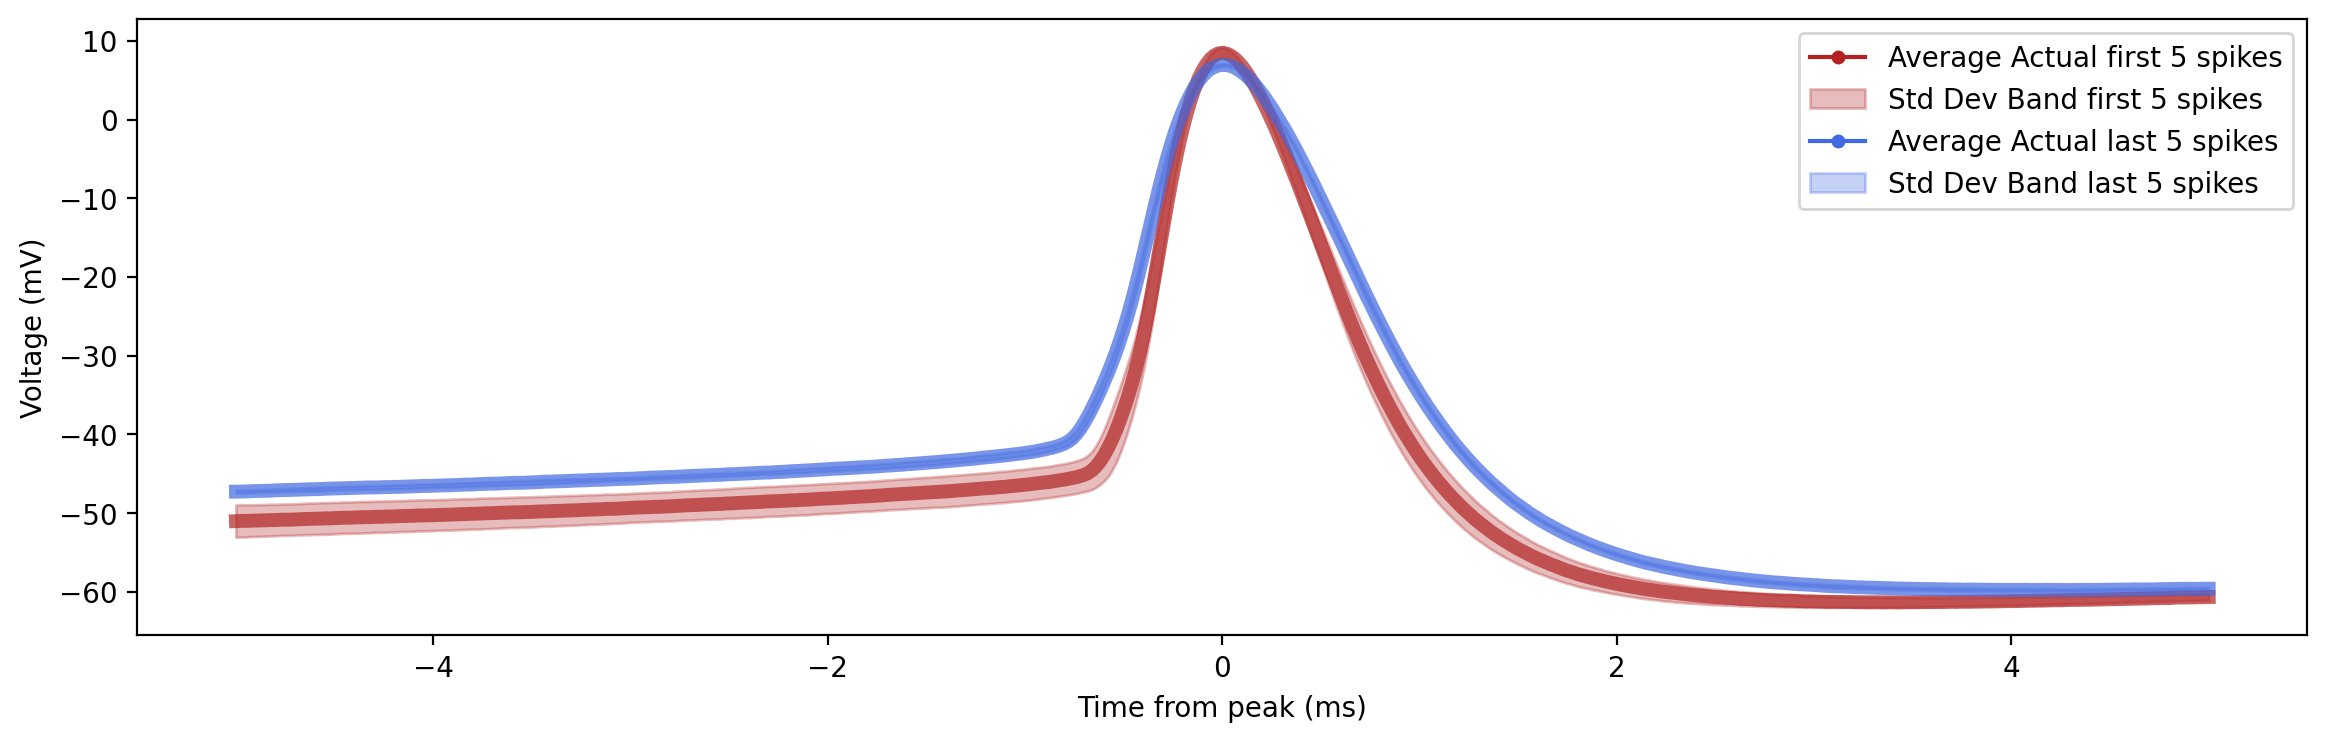

In [5]:
train = df.index[df['sweep'] == 'sweep11'].to_numpy()
sg.plot(groups=True, ind_groups=[train[:5], train[-5:]], group_names=['first 5 spikes', 'last 5 spikes'],
        plot_average=True, plot_average_std=True)
plt.xlabel('Time from peak (ms)')
plt.ylabel('Voltage (mV)')
plt.show()

Next: [Tutorial 3](03_spikes_and_other_signals.ipynb) lines spikes up with a second signal, here the injected current.